# Step 1: Granger Causality Analysis (Optimized)
## Pairwise GC with AIC Optimal Lag + Proportional Threshold

**Input:** Preprocessed EEG `.npy` (62 channels, 100Hz)
**Output:** GC matrices per trial (raw F-statistic + p-values + thresholded)

**Optimasi vs versi lama:**
| Parameter | Lama | Baru |
|---|---|---|
| Max lag | 10 (fixed) | AIC optimal per pair (range 2-5) |
| Threshold | FDR alpha=0.05 (density ~0.97) | Proportional top 10% |
| Target density | ~0.97 (semua terhubung) | ~0.10 (sparse, discriminable) |

**Alur:**
1. Load preprocessed EEG per trial
2. Z-score normalization + stationarity check
3. Compute pairwise GC with AIC-optimal lag
4. Apply proportional threshold (top 10%)
5. Save results per trial

In [1]:
import numpy as np
import os
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


## 1. Konfigurasi

In [2]:
INPUT_DIR = r"D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg"
OUTPUT_DIR = r"D:\Skripsi\new_data\01_granger_causality\output\gc_matrices"
FIGURES_DIR = r"D:\Skripsi\new_data\01_granger_causality\output\figures"

# --- OPTIMIZED PARAMETERS ---
LAG_MIN = 2
LAG_MAX = 5          # AIC selects best from 2-5 (was fixed 10)
PROPORTIONAL_RETAIN = 0.10  # Keep top 10% edges (was FDR ~97%)

N_CHANNELS = 62
TARGET_FS = 100
TRIAL_LABELS = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
EMOTION_MAP = {-1: "negative", 0: "neutral", 1: "positive"}

CHANNEL_NAMES = [
    "Fp1", "Fpz", "Fp2", "AF3", "AF4", "F7", "F5", "F3", "F1", "Fz",
    "F2", "F4", "F6", "F8", "FT7", "FC5", "FC3", "FC1", "FCz", "FC2",
    "FC4", "FC6", "FT8", "T7", "C5", "C3", "C1", "Cz", "C2", "C4",
    "C6", "T8", "TP7", "CP5", "CP3", "CP1", "CPz", "CP2", "CP4", "CP6",
    "TP8", "P7", "P5", "P3", "P1", "Pz", "P2", "P4", "P6", "P8",
    "PO7", "PO5", "PO3", "POz", "PO4", "PO6", "PO8", "CB1", "O1", "Oz",
    "O2", "CB2",
]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Config loaded")
print(f"  Input:  {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Lag range: {LAG_MIN}-{LAG_MAX} (AIC optimal)")
print(f"  Threshold: Proportional top {PROPORTIONAL_RETAIN*100:.0f}%")

Config loaded
  Input:  D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg
  Output: D:\Skripsi\new_data\01_granger_causality\output\gc_matrices
  Lag range: 2-5 (AIC optimal)
  Threshold: Proportional top 10%


## 2. Fungsi Preprocessing

In [3]:
def check_stationarity(ts):
    try:
        result = adfuller(ts, autolag='AIC')
        return result[1] < 0.05
    except:
        return False

def make_stationary(data):
    n_tp, n_ch = data.shape
    result = np.zeros_like(data)
    for ch in range(n_ch):
        ts = data[:, ch]
        if not check_stationarity(ts):
            ts = np.diff(ts)
            result[:len(ts), ch] = ts
            result[len(ts):, ch] = ts[-1]
        else:
            result[:, ch] = ts
    return result

def normalize_channels(data):
    mean = data.mean(axis=0, keepdims=True)
    std = data.std(axis=0, keepdims=True)
    std[std < 1e-10] = 1.0
    return (data - mean) / std

def preprocess_for_gc(eeg_data):
    data = eeg_data.T  # (channels, time) -> (time, channels)
    data = normalize_channels(data)
    data = make_stationary(data)
    return data

print("Preprocessing functions defined")

Preprocessing functions defined


## 3. Fungsi GC dengan AIC-Optimal Lag

In [4]:
def select_optimal_lag(data_pair, lag_min=2, lag_max=5):
    """
    Select optimal lag for a pair of time series using AIC via VAR.
    Returns optimal lag (int).
    """
    best_aic = np.inf
    best_lag = lag_min
    
    for lag in range(lag_min, lag_max + 1):
        try:
            model = VAR(data_pair)
            result = model.fit(lag)
            if result.aic < best_aic:
                best_aic = result.aic
                best_lag = lag
        except:
            continue
    
    return best_lag


def compute_gc_pairwise(data, lag_min=2, lag_max=5):
    """
    Pairwise Granger Causality with AIC-optimal lag per pair.
    
    Args:
        data: (n_timepoints, n_channels) - stationary & normalized
        lag_min, lag_max: range for AIC lag selection
    
    Returns:
        gc_matrix: (n_ch, n_ch) F-statistic values
        p_matrix:  (n_ch, n_ch) p-values
        lag_matrix: (n_ch, n_ch) optimal lag used
    """
    n_ch = data.shape[1]
    gc_matrix = np.zeros((n_ch, n_ch))
    p_matrix = np.ones((n_ch, n_ch))
    lag_matrix = np.zeros((n_ch, n_ch), dtype=int)
    
    for i in range(n_ch):
        for j in range(n_ch):
            if i == j:
                continue
            try:
                test_data = data[:, [j, i]]  # j -> i
                if np.any(np.isnan(test_data)) or np.any(np.isinf(test_data)):
                    continue
                
                # Select optimal lag for this pair
                opt_lag = select_optimal_lag(test_data, lag_min, lag_max)
                lag_matrix[i, j] = opt_lag
                
                result = grangercausalitytests(test_data, maxlag=opt_lag, verbose=False)
                
                # Get result at optimal lag
                f_stat = result[opt_lag][0]['ssr_ftest'][0]
                p_val = result[opt_lag][0]['ssr_ftest'][1]
                
                gc_matrix[i, j] = f_stat
                p_matrix[i, j] = p_val
            except:
                continue
    
    return gc_matrix, p_matrix, lag_matrix

print("GC computation (AIC-optimal lag) defined")

GC computation (AIC-optimal lag) defined


## 4. Proportional Threshold

In [5]:
def apply_proportional_threshold(gc_matrix, retain_ratio=0.10):
    """
    Keep top X% strongest directed edges.
    
    This produces sparse, discriminable connectivity matrices
    suitable for classification.
    """
    n_ch = gc_matrix.shape[0]
    result = gc_matrix.copy()
    np.fill_diagonal(result, 0)
    
    n_possible = n_ch * (n_ch - 1)
    n_keep = max(1, int(n_possible * retain_ratio))
    
    nonzero = result[result > 0]
    if len(nonzero) == 0:
        return result
    
    threshold = np.percentile(nonzero, 100 * (1 - retain_ratio))
    result[result < threshold] = 0
    return result

def compute_density(matrix):
    n = matrix.shape[0]
    return np.count_nonzero(matrix) / (n * (n - 1))

print("Proportional threshold defined")

Proportional threshold defined


## 5. Test pada 1 Trial

In [6]:
# Load one trial
sample_path = os.path.join(INPUT_DIR, "subject_01", "session_20131027", "trial_01.npy")
eeg = np.load(sample_path)
print(f"Loaded: {sample_path}")
print(f"  Shape: {eeg.shape} @ {TARGET_FS}Hz")
print(f"  Label: {TRIAL_LABELS[0]} ({EMOTION_MAP[TRIAL_LABELS[0]]})")

data = preprocess_for_gc(eeg)
print(f"Preprocessed: {data.shape}")

Loaded: D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg\subject_01\session_20131027\trial_01.npy
  Shape: (62, 23501) @ 100Hz
  Label: 1 (positive)
Preprocessed: (23501, 62)


In [7]:
# Compute GC with AIC-optimal lag
print(f"Computing GC (lag {LAG_MIN}-{LAG_MAX}, AIC optimal per pair)...")
t0 = time.time()
gc_raw, p_matrix, lag_matrix = compute_gc_pairwise(data, lag_min=LAG_MIN, lag_max=LAG_MAX)
t1 = time.time()
print(f"Done in {t1-t0:.1f}s")

# Stats
n_possible = N_CHANNELS * (N_CHANNELS - 1)
n_sig = np.count_nonzero(gc_raw)
print(f"\nRaw GC:")
print(f"  Non-zero: {n_sig}/{n_possible}")
print(f"  F-stat: min={gc_raw[gc_raw>0].min():.2f}, max={gc_raw.max():.2f}, mean={gc_raw[gc_raw>0].mean():.2f}")
print(f"  Optimal lags: mean={lag_matrix[lag_matrix>0].mean():.1f}, mode={np.bincount(lag_matrix[lag_matrix>0].flatten()).argmax()}")

Computing GC (lag 2-5, AIC optimal per pair)...
Done in 1773.0s

Raw GC:
  Non-zero: 3782/3782
  F-stat: min=0.10, max=1651.41, mean=68.73
  Optimal lags: mean=5.0, mode=5


Proportional threshold (top 10%):
  Density: 0.100
  Non-zero edges: 379


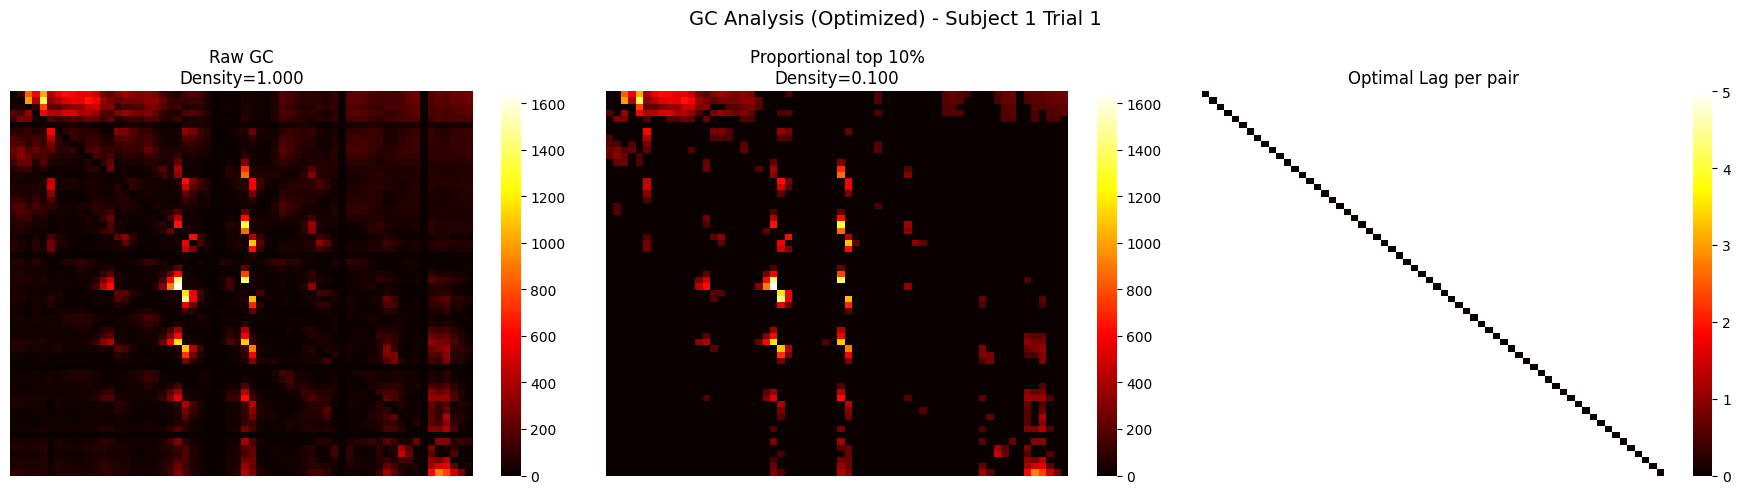

In [8]:
# Apply proportional threshold
gc_thresh = apply_proportional_threshold(gc_raw, retain_ratio=PROPORTIONAL_RETAIN)
density = compute_density(gc_thresh)

print(f"Proportional threshold (top {PROPORTIONAL_RETAIN*100:.0f}%):")
print(f"  Density: {density:.3f}")
print(f"  Non-zero edges: {np.count_nonzero(gc_thresh)}")

# Visualize
# CATATAN: figur versi skripsi dihasilkan ulang oleh
# `new_data/utils/regen_parameter_figures.py` dengan font layak cetak
# (kanvas lebar ini menyusut ~3x saat dimasukkan LaTeX pada \textwidth
# ~5,87 in). Ukuran font di bawah disamakan dengan skrip tersebut agar
# menjalankan notebook ini menghasilkan gambar yang setara.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))
for ax, (title, mat) in zip(axes, [
    ("Raw GC", gc_raw),
    (f"Proportional top {PROPORTIONAL_RETAIN*100:.0f}%", gc_thresh),
    ("Optimal Lag per pair", lag_matrix.astype(float)),
]):
    sns.heatmap(mat, cmap='hot', ax=ax, xticklabels=False, yticklabels=False)
    ax.set_title(f"{title}\nDensity={compute_density(mat):.3f}" if 'Lag' not in title else title,
                 fontsize=27, fontweight='bold')
    ax.set_xlabel("Kanal sumber", fontsize=23)
    ax.set_ylabel("Kanal target", fontsize=23)

plt.suptitle("GC Analysis (Optimized) - Subject 1 Trial 1", fontsize=34,
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gc_optimized_sample.png"), dpi=150, bbox_inches='tight')
plt.show()

## 6. Run GC untuk Semua Trial
### Auto-skip jika sudah ada di output

In [9]:
# Scan semua trial
trial_list = []
total_trials = 0
done_trials = 0

for subj_dir in sorted(os.listdir(INPUT_DIR)):
    subj_path = os.path.join(INPUT_DIR, subj_dir)
    if not os.path.isdir(subj_path):
        continue
    for sess_dir in sorted(os.listdir(subj_path)):
        sess_path = os.path.join(subj_path, sess_dir)
        if not os.path.isdir(sess_path):
            continue
        for trial_file in sorted(os.listdir(sess_path)):
            if not trial_file.endswith('.npy'):
                continue
            trial_idx = int(trial_file.split('_')[1].split('.')[0])
            out_dir = os.path.join(OUTPUT_DIR, subj_dir, sess_dir)
            gc_out = os.path.join(out_dir, f'gc_raw_trial_{trial_idx:02d}.npy')
            thresh_out = os.path.join(out_dir, f'gc_thresholded_trial_{trial_idx:02d}.npy')
            
            # Check if done with NEW format (has lag_matrix)
            lag_out = os.path.join(out_dir, f'gc_lag_trial_{trial_idx:02d}.npy')
            done = os.path.exists(gc_out) and os.path.exists(thresh_out) and os.path.exists(lag_out)
            if done:
                done_trials += 1
            
            trial_list.append({
                'subj_dir': subj_dir,
                'sess_dir': sess_dir,
                'trial_file': trial_file,
                'trial_idx': trial_idx,
                'done': done,
            })
            total_trials += 1

print(f"Total trials: {total_trials}")
print(f"Already done: {done_trials}")
print(f"Remaining:    {total_trials - done_trials}")

Total trials: 630
Already done: 608
Remaining:    22


In [10]:
# Run GC for all trials
metadata = {
    "lag_min": LAG_MIN, "lag_max": LAG_MAX,
    "threshold_method": f"proportional_{PROPORTIONAL_RETAIN}",
    "subjects": {}
}
all_densities = []
processed = 0
skipped = 0
computed = 0
start_all = time.time()

for trial_info in trial_list:
    subj_dir = trial_info['subj_dir']
    sess_dir = trial_info['sess_dir']
    trial_file = trial_info['trial_file']
    trial_idx = trial_info['trial_idx']
    already_done = trial_info['done']
    
    out_dir = os.path.join(OUTPUT_DIR, subj_dir, sess_dir)
    os.makedirs(out_dir, exist_ok=True)
    
    gc_raw_path = os.path.join(out_dir, f'gc_raw_trial_{trial_idx:02d}.npy')
    p_mat_path = os.path.join(out_dir, f'p_values_trial_{trial_idx:02d}.npy')
    lag_path = os.path.join(out_dir, f'gc_lag_trial_{trial_idx:02d}.npy')
    thresh_path = os.path.join(out_dir, f'gc_thresholded_trial_{trial_idx:02d}.npy')

    label = TRIAL_LABELS[trial_idx - 1]
    processed += 1

    if already_done:
        gc_thresh = np.load(thresh_path)
        density = compute_density(gc_thresh)
        skipped += 1
        print(f"  [{processed}/{total_trials}] SKIP {subj_dir}/{sess_dir}/trial_{trial_idx:02d} ({EMOTION_MAP[label]}) - density={density:.3f}")
    else:
        eeg = np.load(os.path.join(INPUT_DIR, subj_dir, sess_dir, trial_file))
        data = preprocess_for_gc(eeg)
        
        t0 = time.time()
        gc_raw, p_mat, lag_mat = compute_gc_pairwise(data, lag_min=LAG_MIN, lag_max=LAG_MAX)
        gc_thresh = apply_proportional_threshold(gc_raw, retain_ratio=PROPORTIONAL_RETAIN)
        t1 = time.time()
        
        density = compute_density(gc_thresh)
        computed += 1

        np.save(gc_raw_path, gc_raw)
        np.save(p_mat_path, p_mat)
        np.save(lag_path, lag_mat)
        np.save(thresh_path, gc_thresh)

        print(f"  [{processed}/{total_trials}] DONE {subj_dir}/{sess_dir}/trial_{trial_idx:02d} ({EMOTION_MAP[label]}) - {t1-t0:.1f}s, density={density:.3f}")

    all_densities.append(density)

    if subj_dir not in metadata["subjects"]:
        metadata["subjects"][subj_dir] = {}
    if sess_dir not in metadata["subjects"][subj_dir]:
        metadata["subjects"][subj_dir][sess_dir] = {"n_trials": 0, "densities": []}
    metadata["subjects"][subj_dir][sess_dir]["n_trials"] += 1
    metadata["subjects"][subj_dir][sess_dir]["densities"].append(density)

total_time = time.time() - start_all
metadata["total_trials"] = total_trials
metadata["total_time_min"] = round(total_time / 60, 1)
metadata["overall_mean_density"] = float(np.mean(all_densities))

for subj, sessions in metadata["subjects"].items():
    for sess, info in sessions.items():
        info["mean_density"] = float(np.mean(info["densities"]))
        del info["densities"]

meta_path = os.path.join(OUTPUT_DIR, "gc_metadata.json")
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n{'='*50}")
print(f"Done! {total_trials} trials ({skipped} skipped, {computed} computed)")
print(f"Time: {total_time/60:.1f} min")
print(f"Mean density: {np.mean(all_densities):.3f}")

  [1/630] SKIP subject_01/session_20131027/trial_01 (positive) - density=0.100
  [2/630] SKIP subject_01/session_20131027/trial_02 (neutral) - density=0.100
  [3/630] SKIP subject_01/session_20131027/trial_03 (negative) - density=0.100
  [4/630] SKIP subject_01/session_20131027/trial_04 (negative) - density=0.100
  [5/630] SKIP subject_01/session_20131027/trial_05 (neutral) - density=0.100
  [6/630] SKIP subject_01/session_20131027/trial_06 (positive) - density=0.100
  [7/630] SKIP subject_01/session_20131027/trial_07 (negative) - density=0.100
  [8/630] SKIP subject_01/session_20131027/trial_08 (neutral) - density=0.100
  [9/630] SKIP subject_01/session_20131027/trial_09 (positive) - density=0.100
  [10/630] SKIP subject_01/session_20131027/trial_10 (positive) - density=0.100
  [11/630] SKIP subject_01/session_20131027/trial_11 (neutral) - density=0.100
  [12/630] SKIP subject_01/session_20131027/trial_12 (negative) - density=0.100
  [13/630] SKIP subject_01/session_20131027/trial_13 

## 7. Analisis Density

=== GC Density Summary (Optimized) ===
          count      mean           std       min       25%       50%  \
emotion                                                                 
negative  210.0  0.100212  1.391095e-17  0.100212  0.100212  0.100212   
neutral   210.0  0.100212  1.391095e-17  0.100212  0.100212  0.100212   
positive  210.0  0.100212  1.391095e-17  0.100212  0.100212  0.100212   

               75%       max  
emotion                       
negative  0.100212  0.100212  
neutral   0.100212  0.100212  
positive  0.100212  0.100212  

Overall mean density: 0.100
Target density: ~0.10


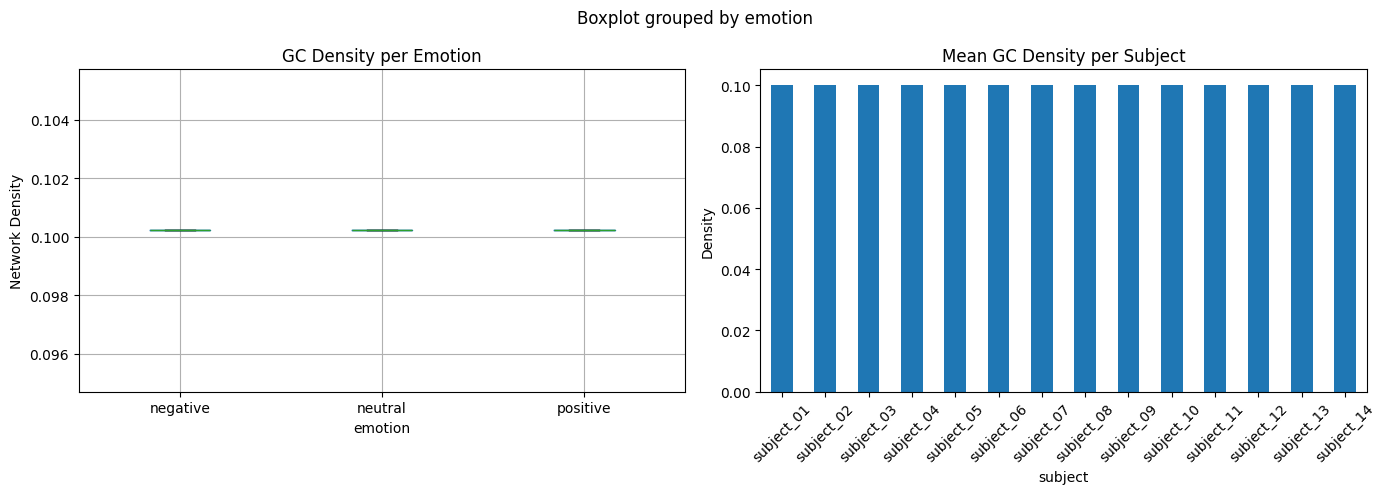

In [11]:
import pandas as pd

all_data = []
for subj_dir in sorted(os.listdir(OUTPUT_DIR)):
    subj_path = os.path.join(OUTPUT_DIR, subj_dir)
    if not os.path.isdir(subj_path):
        continue
    for sess_dir in sorted(os.listdir(subj_path)):
        sess_path = os.path.join(subj_path, sess_dir)
        if not os.path.isdir(sess_path):
            continue
        for f in sorted(os.listdir(sess_path)):
            if 'thresholded' in f and f.endswith('.npy'):
                matrix = np.load(os.path.join(sess_path, f))
                trial_idx = int(f.split('_')[-1].split('.')[0])
                label = TRIAL_LABELS[trial_idx - 1]
                all_data.append({
                    'subject': subj_dir,
                    'session': sess_dir,
                    'trial': trial_idx,
                    'emotion': EMOTION_MAP[label],
                    'density': compute_density(matrix),
                    'n_edges': np.count_nonzero(matrix),
                })

df_density = pd.DataFrame(all_data)

print("=== GC Density Summary (Optimized) ===")
print(df_density.groupby('emotion')['density'].describe())
print(f"\nOverall mean density: {df_density['density'].mean():.3f}")
print(f"Target density: ~{PROPORTIONAL_RETAIN:.2f}")

# CATATAN: figur versi skripsi dihasilkan ulang oleh
# `new_data/utils/regen_parameter_figures.py` dengan font layak cetak
# (kanvas lebar ini menyusut ~3x saat dimasukkan LaTeX pada \textwidth
# ~5,87 in). Ukuran font di bawah disamakan dengan skrip tersebut agar
# menjalankan notebook ini menghasilkan gambar yang setara.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df_density.boxplot(column='density', by='emotion', ax=axes[0])
axes[0].set_title("GC Density per Emotion", fontsize=27, fontweight="bold")
axes[0].set_ylabel("Network Density", fontsize=23)

df_density.groupby('subject')['density'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title("Mean GC Density per Subject", fontsize=27, fontweight="bold")
axes[1].set_ylabel("Density", fontsize=23)
for _ax in axes:
    _ax.tick_params(axis='both', labelsize=20)
plt.setp(axes[1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gc_density_analysis_optimized.png"), dpi=150, bbox_inches='tight')
plt.show()